In [1]:
import pandas as pd

In [2]:
nvidia = pd.read_csv('nvidia_with_features.csv')

## Logistic Regression Model

In [3]:
nvidia['Target'] = (nvidia['Close'].shift(-1) > nvidia['Close']).astype(int)

In [4]:
nvidia.dropna(inplace=True)

In [5]:
features = [
    'Close',
    'Volume',
    'Returns',
    'Volatility',
    'RSI',
    'MACD',
    'Signal_Line',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'Volume_Change',
    'Volume_MA20'
]

In [6]:
X = nvidia[features]

y = nvidia['Target']

In [7]:
from sklearn.model_selection import train_test_split

split = int(len(nvidia) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

log_pred = (log_prob > 0.55).astype(int)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

log_accuracy = accuracy_score(y_test, log_pred)

log_precision = precision_score(y_test, log_pred)

log_recall = recall_score(y_test, log_pred)

log_f1 = f1_score(y_test, log_pred)

log_cm = confusion_matrix(y_test, log_pred)

log_report = classification_report(y_test, log_pred)

print("Logistic Regression Results")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1 Score:", log_f1)
print("Confusion Matrix:\n", log_cm)
print("Classification Report:\n", log_report)

Logistic Regression Results
Accuracy: 0.5211267605633803
Precision: 0.5383867832847424
Recall: 0.7641379310344828
F1 Score: 0.6316989737742303
Confusion Matrix:
 [[149 475]
 [171 554]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.24      0.32       624
           1       0.54      0.76      0.63       725

    accuracy                           0.52      1349
   macro avg       0.50      0.50      0.47      1349
weighted avg       0.50      0.52      0.49      1349



In [12]:
lr_pred = pd.DataFrame(log_pred, columns=['Logistic_Prediction'])

In [13]:
lr_pred.value_counts(), y_test.value_counts()

(Logistic_Prediction
 1                      1029
 0                       320
 Name: count, dtype: int64,
 Target
 1    725
 0    624
 Name: count, dtype: int64)

-Stock price goes up more than it goes down. Hence, the model predicts UP more than DOWN.

In [31]:
train_acc = log_model.score(X_train_scaled, y_train)
test_acc = log_model.score(X_test_scaled, y_test)

print(train_acc)
print(test_acc)

0.5277108433734939
0.5270570793180134


## Random Forrest Classifier

In [73]:
nvidia['Target'] = (nvidia['Close'].shift(-1) > nvidia['Close']).astype(int)

In [74]:
nvidia.dropna(inplace=True)

In [75]:
nvidia['Price_vs_MA20'] = nvidia['Close'] / nvidia['MA20']
nvidia['Price_vs_MA50'] = nvidia['Close'] / nvidia['MA50']

nvidia['MA20_vs_MA50'] = nvidia['MA20'] / nvidia['MA50']

In [76]:
ema12 = nvidia['Close'].ewm(span=12).mean()
ema26 = nvidia['Close'].ewm(span=26).mean()

nvidia['EMA_Ratio'] = ema12 / ema26

In [79]:
features = [
    'Volume',
    'Returns',
    'Price_vs_MA20',
    'Price_vs_MA50',
    'MA20_vs_MA50',
    'Volatility',
    'RSI',
    'MACD',
    'Momentum',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_5',
    'Lag_R1',
    'Lag_R2',
    'Volume_Change',
    'Volume_MA20',
    'BB_Width',
    'EMA_Ratio'
]

In [80]:
X = nvidia[features]

y = nvidia['Target']

In [81]:
from sklearn.model_selection import train_test_split

split = int(len(nvidia) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
rf_pred = rf_model.predict(X_test)

In [84]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_cm = confusion_matrix(y_test, rf_pred)

rf_report = classification_report(y_test, rf_pred)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("Confusion Matrix:\n", rf_cm)
print("Classification Report:\n", rf_report)



Random Forest Results
Accuracy: 0.5174203113417346
Precision: 0.5396995708154506
Recall: 0.6937931034482758
F1 Score: 0.6071213035606517
Confusion Matrix:
 [[195 429]
 [222 503]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.31      0.37       624
           1       0.54      0.69      0.61       725

    accuracy                           0.52      1349
   macro avg       0.50      0.50      0.49      1349
weighted avg       0.51      0.52      0.50      1349



In [139]:
rf_pred = pd.DataFrame(rf_pred, columns=['Random_Forest_Prediction'])

In [140]:
rf_pred.value_counts(), y_test.value_counts()

(Random_Forest_Prediction
 1                           932
 0                           417
 Name: count, dtype: int64,
 Target
 1    724
 0    623
 Name: count, dtype: int64)

In [95]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
15  Volume_Change    0.060494
13         Lag_R1    0.059818
1         Returns    0.059753
5      Volatility    0.057209
14         Lag_R2    0.057078
0          Volume    0.056489
8        Momentum    0.055464
16    Volume_MA20    0.054906
4    MA20_vs_MA50    0.054310
6             RSI    0.053996
17       BB_Width    0.053690
2   Price_vs_MA20    0.051958
18      EMA_Ratio    0.049960
7            MACD    0.048629
3   Price_vs_MA50    0.047701
10          Lag_2    0.047459
12          Lag_5    0.046470
9           Lag_1    0.043370
11          Lag_3    0.041246


#### ROC Score

In [86]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)
print(roc_auc)

0.5102276746242262


#### Training vs Test accuracy

In [85]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.905097312326228
0.5174203113417346


## XGBoost Classifier

In [87]:
nvidia['Target'] = (nvidia['Close'].shift(-1) > nvidia['Close']).astype(int)

In [122]:
nvidia['Lag_R3'] = nvidia['Returns'].shift(3)
nvidia['Lag_R5'] = nvidia['Returns'].shift(5)
nvidia['Lag_R10'] = nvidia['Returns'].shift(10)

In [130]:
features = [
    'Returns',
    'Price_vs_MA20',
    'MA20_vs_MA50',
    'Volatility',
    'RSI',
    'MACD',
    'Momentum',
    'Lag_R1',
    'Lag_R2',
    'Volume_Change',
    'BB_Width',
    'EMA_Ratio',
]

In [131]:
X = nvidia[features]

y = nvidia['Target']

In [132]:
nvidia.dropna(inplace=True)

In [133]:
from sklearn.model_selection import TimeSeriesSplit

split = int(len(nvidia) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [134]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [135]:
xgb_pred = xgb_model.predict(X_test)

In [143]:
xgb_pred.value_counts(), y_test.value_counts()

(XGBoost_Prediction
 1                     906
 0                     441
 Name: count, dtype: int64,
 Target
 1    724
 0    623
 Name: count, dtype: int64)

In [136]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_cm = confusion_matrix(y_test, xgb_pred)

xgb_report = classification_report(y_test, xgb_pred)

print("XGBoost Results")
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)
print("Confusion Matrix:\n", xgb_cm)
print("Classification Report:\n", xgb_report)

XGBoost Results
Accuracy: 0.49665924276169265
Precision: 0.5253863134657837
Recall: 0.6574585635359116
F1 Score: 0.5840490797546012
Confusion Matrix:
 [[193 430]
 [248 476]]
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.31      0.36       623
           1       0.53      0.66      0.58       724

    accuracy                           0.50      1347
   macro avg       0.48      0.48      0.47      1347
weighted avg       0.48      0.50      0.48      1347



In [146]:
xgb_pred = pd.DataFrame(xgb_pred, columns=['XGBoost_Prediction'])
xgb_pred.value_counts(), y_test.value_counts()

(XGBoost_Prediction
 1                     906
 0                     441
 Name: count, dtype: int64,
 Target
 1    724
 0    623
 Name: count, dtype: int64)

In [137]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
10       BB_Width    0.086978
0         Returns    0.084567
9   Volume_Change    0.083916
7          Lag_R1    0.083895
1   Price_vs_MA20    0.083551
5            MACD    0.083251
3      Volatility    0.083099
4             RSI    0.082486
2    MA20_vs_MA50    0.082471
6        Momentum    0.082370
11      EMA_Ratio    0.081756
8          Lag_R2    0.081660


In [121]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        log_precision,
        rf_precision,
        xgb_precision
    ],
    'Recall': [
        log_recall,
        rf_recall,
        xgb_recall
    ],
    'F1 Score': [
        log_f1,
        rf_f1,
        xgb_f1
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.521127   0.538387  0.764138  0.631699
1        Random Forest  0.517420   0.539700  0.693793  0.607121
2              XGBoost  0.507042   0.534483  0.641379  0.583072


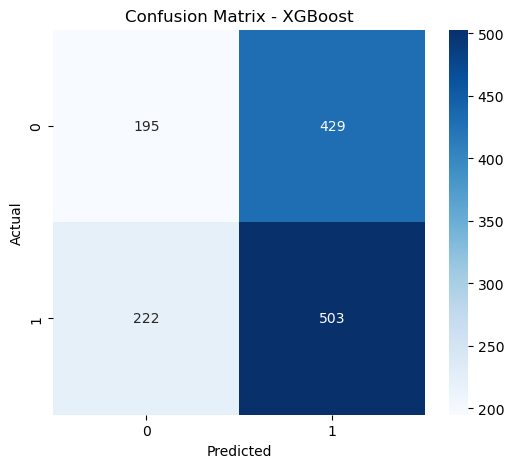

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - XGBoost')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()